# Model Train

In [3]:
import pandas as pd 
import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [4]:
df = pd.read_csv("/kaggle/input/insurance/insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Train/Validation/Test Split

In [5]:
X = df.drop('charges', axis=1)
y = df['charges']

y_binned = pd.qcut(y, q = 10, duplicates='drop')

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y_binned,random_state = 42
)

y_temp_binned = pd.qcut(y_temp, q=10, duplicates='drop')

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size = 0.25, stratify = y_temp_binned, random_state = 42 
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (802, 6) (802,)
Validation: (268, 6) (268,)
Test: (268, 6) (268,)


## Outlier Removal

In [6]:
from scipy.stats import zscore
import numpy as np
import pandas as pd

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

for col in num_cols:
    initial_skew = X_train[col].skew(skipna=True)
    print(f"\nColumn: {col}")
    print(f"  Initial skew: {initial_skew:.4f}")

    if abs(initial_skew) > 1:
        q1, q3 = X_train[col].quantile([0.25, 0.75])
        IQR = q3 - q1
        lower, upper = q1 - 1.5 * IQR, q3 + 1.5 * IQR
        mask = (X_train[col] >= lower) & (X_train[col] <= upper)
        outliers = (~mask).sum()
        X_train.loc[~mask, col] = np.nan
        print(f"  Used IQR — Outliers removed: {outliers}")
    else:
        z_scores = np.abs(zscore(X_train[col].dropna()))
        mask = (z_scores <= 3)
        outliers = (~mask).sum()

        valid_idx = X_train[col].dropna().index
        X_train.loc[valid_idx[~mask], col] = np.nan
        print(f"  Used Z-score — Outliers removed: {outliers}")

    new_skew = X_train[col].skew(skipna=True)
    print(f"  New skew: {new_skew:.4f}")


Numeric columns: ['age', 'bmi', 'children']
Categorical columns: ['sex', 'smoker', 'region']

Column: age
  Initial skew: 0.0597
  Used Z-score — Outliers removed: 0
  New skew: 0.0597

Column: bmi
  Initial skew: 0.2725
  Used Z-score — Outliers removed: 2
  New skew: 0.1874

Column: children
  Initial skew: 0.9449
  Used Z-score — Outliers removed: 11
  New skew: 0.7244


In [7]:
skews = X_train[num_cols].apply(lambda x: x.skew())
normal_features = skews[abs(skews) < 0.5].index.tolist()
moderate_features = skews[(abs(skews) >= 0.5) & (abs(skews)<2)].index.tolist()


## Pipelines

## Numeric Pipelines

In [8]:
standard_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

robust_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', RobustScaler())
])


## Categorical Pipelines

In [9]:
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False))
])

## Preprocessor

In [10]:
preprocessor = ColumnTransformer([
    ('standard', standard_pipe, normal_features),
    ('robust', robust_pipe, moderate_features),
    ('cat', cat_pipe, cat_cols)
])

# Fit multiple regressors

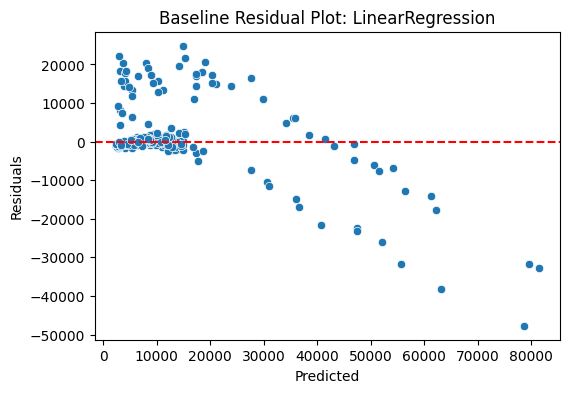

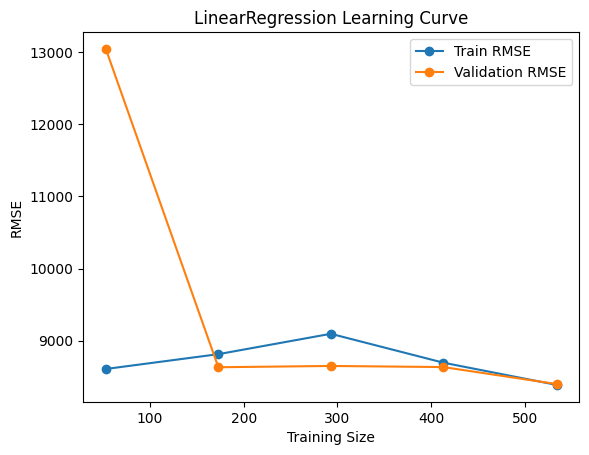

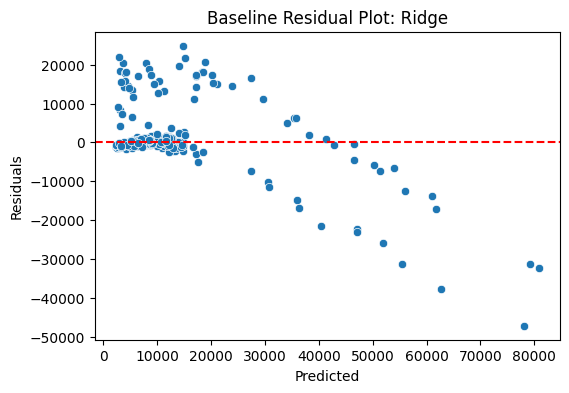

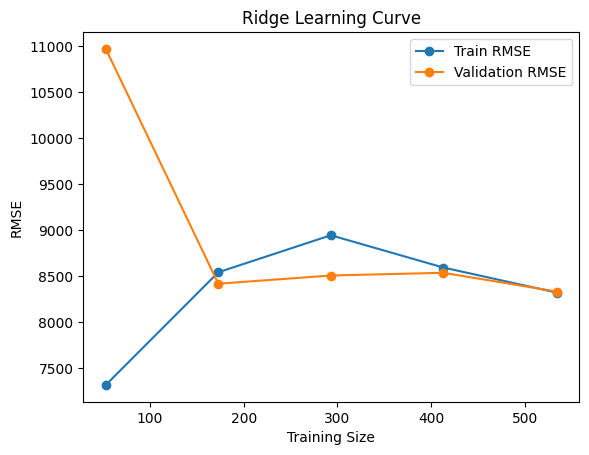

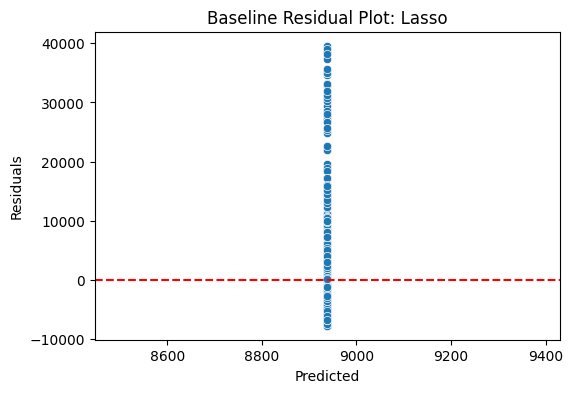

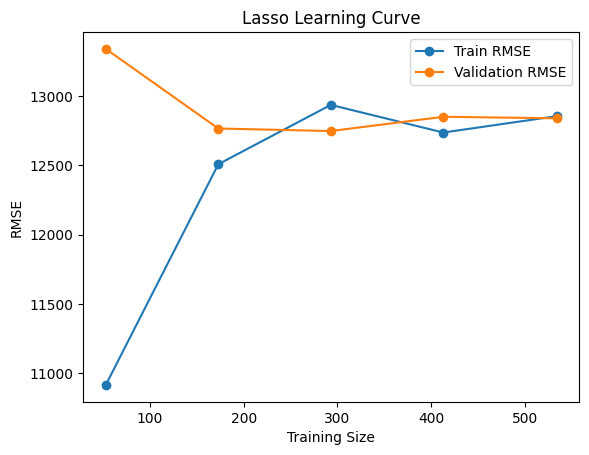

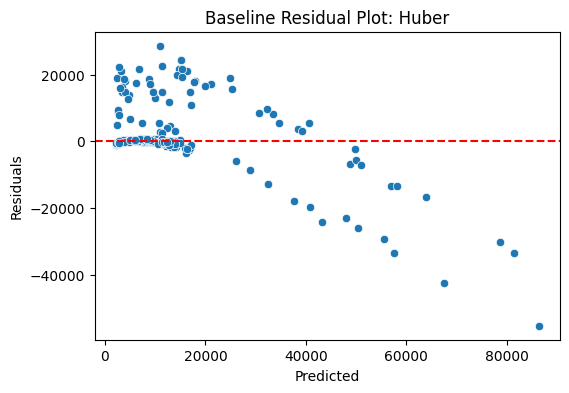

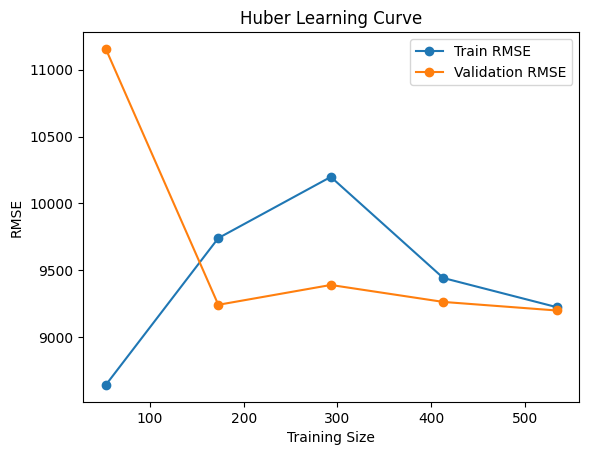

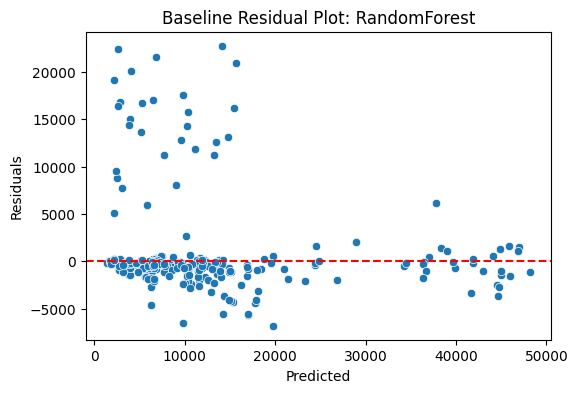

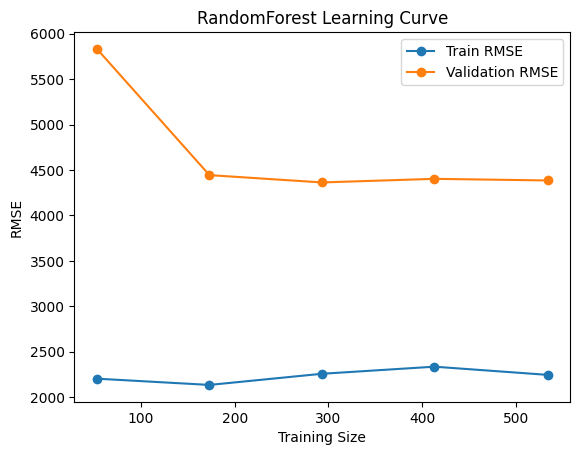

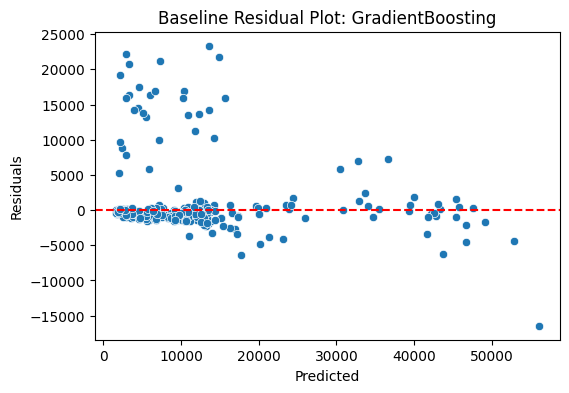

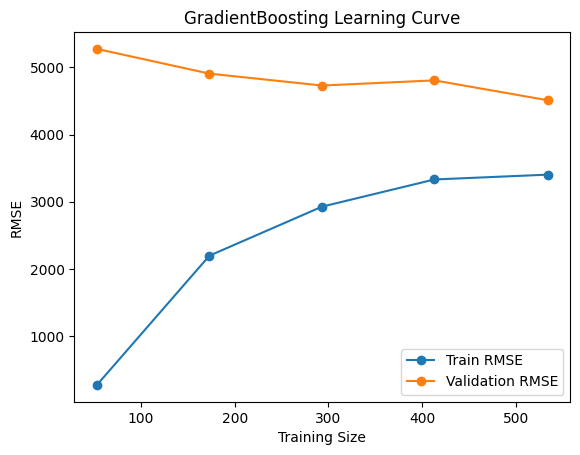

              model      val_rmse    val_r2
4      RandomForest   5221.232499  0.804997
5  GradientBoosting   5369.515121  0.793764
1             Ridge   8919.827850  0.430874
0  LinearRegression   8972.425456  0.424143
3             Huber   9696.303675  0.327476
2             Lasso  12573.690305 -0.130891


In [11]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import seaborn as sns

y_skew = pd.Series(y_train).skew() 
use_target_log = (abs(y_skew) > 1) and (y_train.min() >= 0)


def plot_learning_curve(estimator, X, y, title='Learning Curve'):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=3, scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1,1.0,5), n_jobs=-1
    )
    train_scores_mean = -np.mean(train_scores, axis=1)
    val_scores_mean = -np.mean(val_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_scores_mean, 'o-', label='Train RMSE')
    plt.plot(train_sizes, val_scores_mean, 'o-', label='Validation RMSE')
    plt.xlabel('Training Size')
    plt.ylabel('RMSE')
    plt.title(title)
    plt.legend()
    plt.show()



models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Huber': HuberRegressor(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    reg_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    if use_target_log:
        estimator = TransformedTargetRegressor(
            regressor = reg_pipe,
            func = np.log1p,
            inverse_func = np.expm1
        )
    else:
        estimator = reg_pipe

    estimator.fit(X_train, y_train)
    y_val_pred = estimator.predict(X_val)    

    rmse = mean_squared_error(y_val, y_val_pred, squared=False)
    r2 = r2_score(y_val, y_val_pred)

    residuals = y_val - y_val_pred
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=y_val_pred, y=residuals)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residuals')
    plt.title(f'Baseline Residual Plot: {name}')
    plt.show()

    plot_learning_curve(estimator, X_train, y_train, title=f'{name} Learning Curve')

    results.append({'model':name, 'val_rmse':rmse, 'val_r2':r2})

results_df = pd.DataFrame(results).sort_values(by='val_rmse')
print(results_df)

# Hyperparameter tuning

## Hyperparameter grids

In [12]:
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

 
rf_pipe = Pipeline([('preprocessor', preprocessor),
                    ('model', RandomForestRegressor(random_state=42))])

gb_pipe = Pipeline([('preprocessor', preprocessor),
                    ('model', GradientBoostingRegressor(random_state=42))])

 
if use_target_log:
    rf_estimator = TransformedTargetRegressor(rf_pipe, func=np.log1p, inverse_func=np.expm1)
    gb_estimator = TransformedTargetRegressor(gb_pipe, func=np.log1p, inverse_func=np.expm1)
else:
    rf_estimator = rf_pipe
    gb_estimator = gb_pipe
 
rf_param_dist = {
    'regressor__model__n_estimators': [100, 200, 300],
    'regressor__model__max_depth': [None, 5, 10, 20],
    'regressor__model__min_samples_split': [2, 5, 10],
    'regressor__model__min_samples_leaf': [1, 2, 4],
    'regressor__model__max_features': [1.0, 'sqrt', 'log2']
}

gb_param_dist = {
    'regressor__model__n_estimators': [100, 200, 300],
    'regressor__model__learning_rate': [0.01, 0.05, 0.1],
    'regressor__model__max_depth': [3, 5, 7],
    'regressor__model__min_samples_split': [2, 5, 10],
    'regressor__model__min_samples_leaf': [1, 2, 4]
}



## PLot and Metrics

In [13]:
def plot_diagnostics(y_true, y_pred, title_prefix=''):
    residuals = y_true - y_pred

    plt.figure(figsize=(14,5))

    # Residuals plot
    plt.subplot(1,2,1)
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residuals')
    plt.title(f'{title_prefix} Residuals')

    # Actual vs Predicted
    plt.subplot(1,2,2)
    sns.scatterplot(x=y_true, y=y_pred)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{title_prefix} Actual vs Predicted')

    plt.show()


def print_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'RMSE: {rmse:.3f}, MAE: {mae:.3f}, R2: {r2:.3f}')


## Tune RandomForest

In [14]:
rf_search = RandomizedSearchCV(
    rf_estimator,
    param_distributions=rf_param_dist,
    n_iter=20, cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)

Best RF params: {'regressor__model__n_estimators': 100, 'regressor__model__min_samples_split': 10, 'regressor__model__min_samples_leaf': 4, 'regressor__model__max_features': 1.0, 'regressor__model__max_depth': 10}


## Tune GradientBoosting

In [15]:
gb_search = RandomizedSearchCV(
    gb_estimator,
    param_distributions=gb_param_dist,
    n_iter=20, cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)
gb_search.fit(X_train, y_train)
best_gb = gb_search.best_estimator_
print("Best GB params:", gb_search.best_params_)

Best GB params: {'regressor__model__n_estimators': 200, 'regressor__model__min_samples_split': 2, 'regressor__model__min_samples_leaf': 4, 'regressor__model__max_depth': 5, 'regressor__model__learning_rate': 0.05}


## Evaluate Tuned Models


RandomForest Validation Metrics:
RMSE: 5204.493, MAE: 2415.189, R2: 0.806


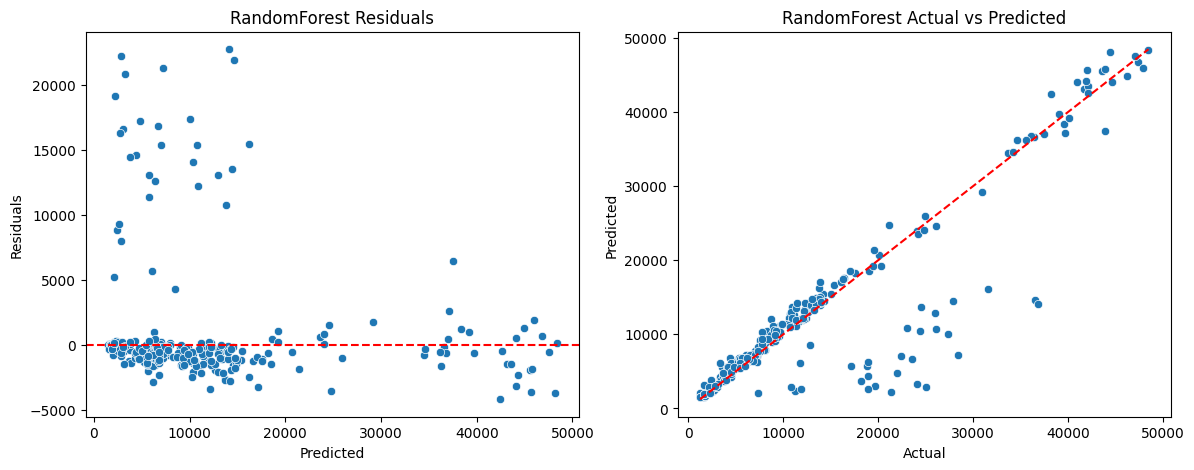

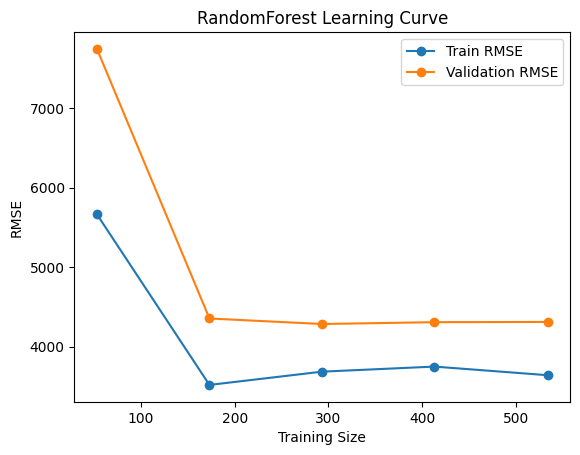


GradientBoosting Validation Metrics:
RMSE: 5245.206, MAE: 2547.825, R2: 0.803


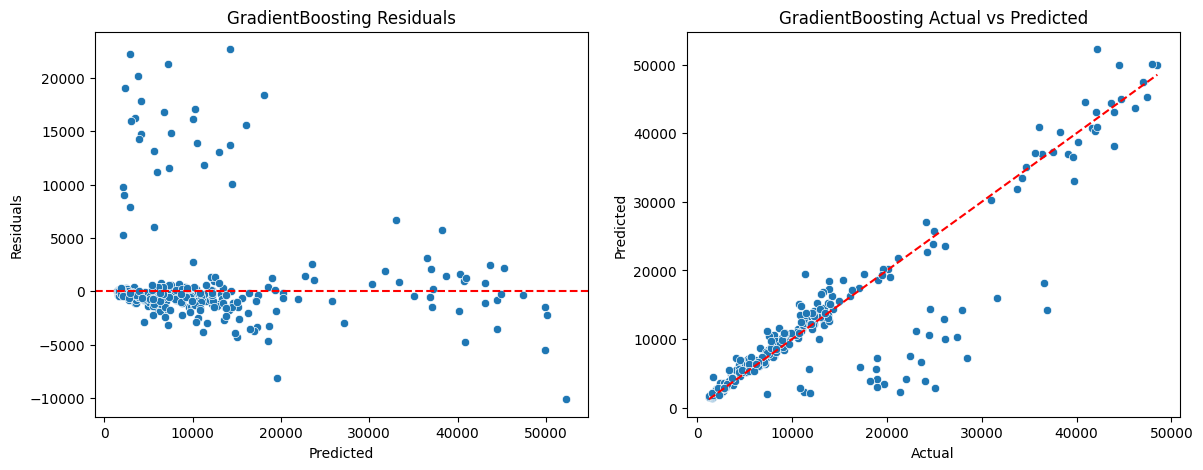

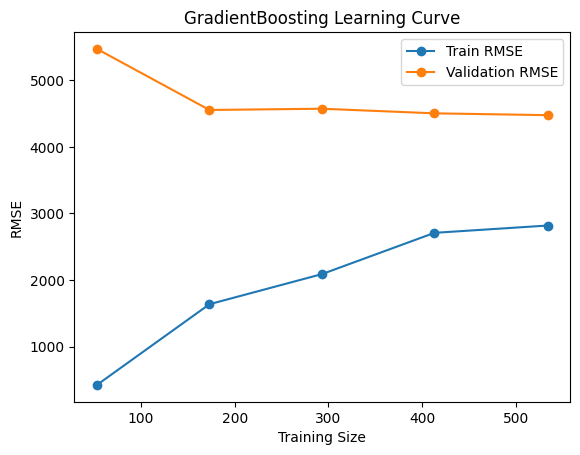

In [16]:
for name, model in zip(['RandomForest', 'GradientBoosting'], [best_rf, best_gb]):
    print(f"\n{name} Validation Metrics:")
    y_val_pred = model.predict(X_val)
    print_metrics(y_val, y_val_pred)
    plot_diagnostics(y_val, y_val_pred, title_prefix=name)
    plot_learning_curve(model, X_train, y_train, title=f'{name} Learning Curve')

## Evalute Final Test Metrics


RandomForest Test Metrics:
RMSE: 4589.604, MAE: 2106.361, R2: 0.863


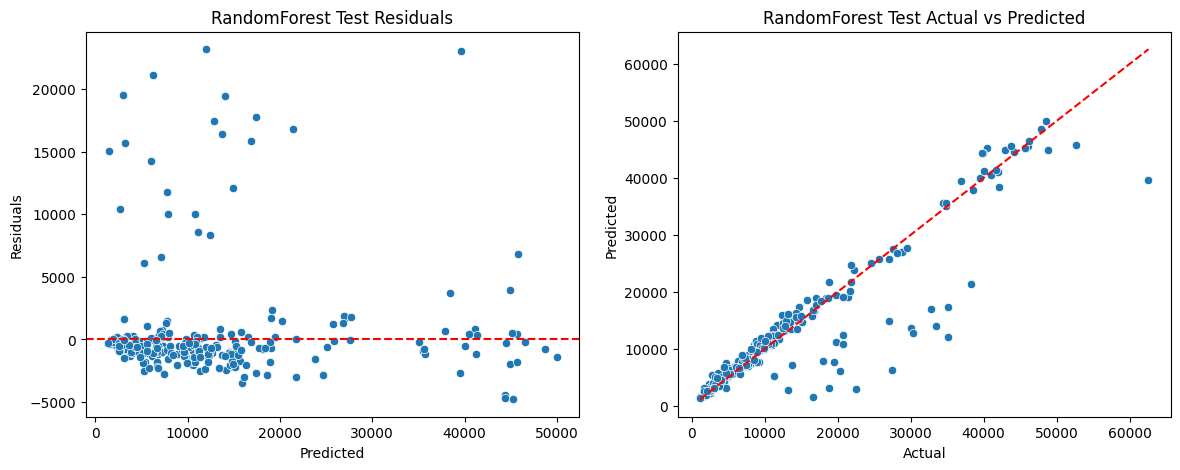

RandomForest model saved at: /kaggle/working/RandomForest_insurance_model.pkl

GradientBoosting Test Metrics:
RMSE: 4936.015, MAE: 2287.638, R2: 0.841


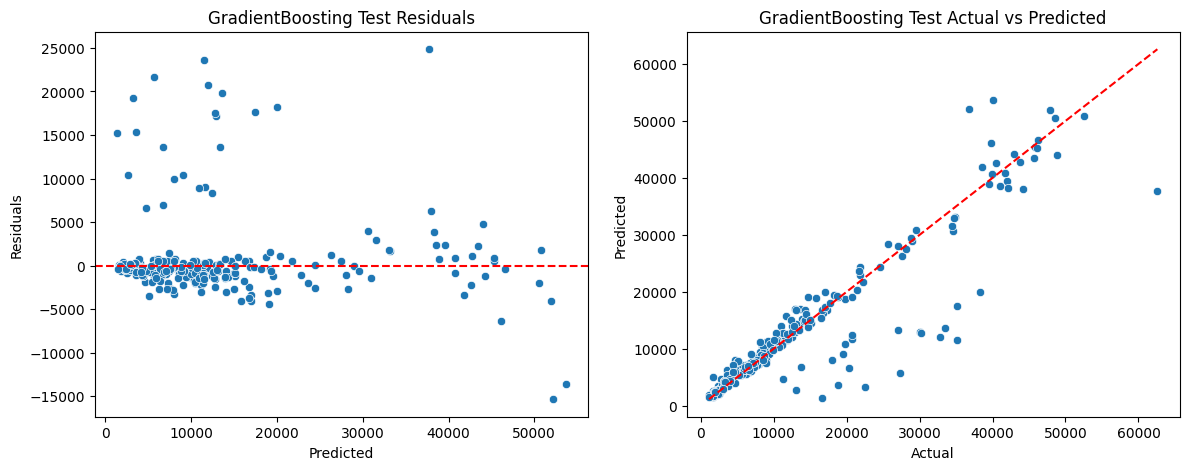

GradientBoosting model saved at: /kaggle/working/GradientBoosting_insurance_model.pkl


In [17]:
import joblib

for name, model in zip(['RandomForest', 'GradientBoosting'], [best_rf, best_gb]):
    print(f"\n{name} Test Metrics:")
    y_test_pred = model.predict(X_test)
    print_metrics(y_test, y_test_pred)
    plot_diagnostics(y_test, y_test_pred, title_prefix=f'{name} Test')

    save_path = f"/kaggle/working/{name}_insurance_model.pkl"
    joblib.dump(model, save_path)
    print(f"{name} model saved at: {save_path}")

# Interpretability

In [18]:
import joblib

model_path = "/kaggle/working/GradientBoosting_insurance_model.pkl"
model = joblib.load(model_path)

print("Model loaded")

Model loaded


## Unwrap 

In [31]:
ttr = model
pipe = ttr.regressor_
gb_model = pipe.named_steps["model"]
preprocessor = pipe.named_steps["preprocessor"]

## Feature Importance

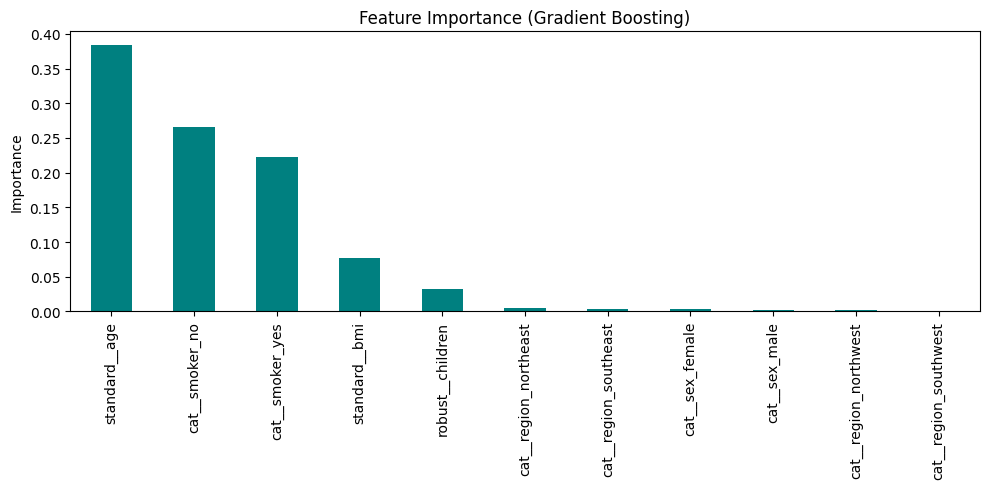

In [36]:
importances = gb_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,5))
feat_imp.plot(kind='bar', color='teal')
plt.title("Feature Importance (Gradient Boosting)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


## SHAP

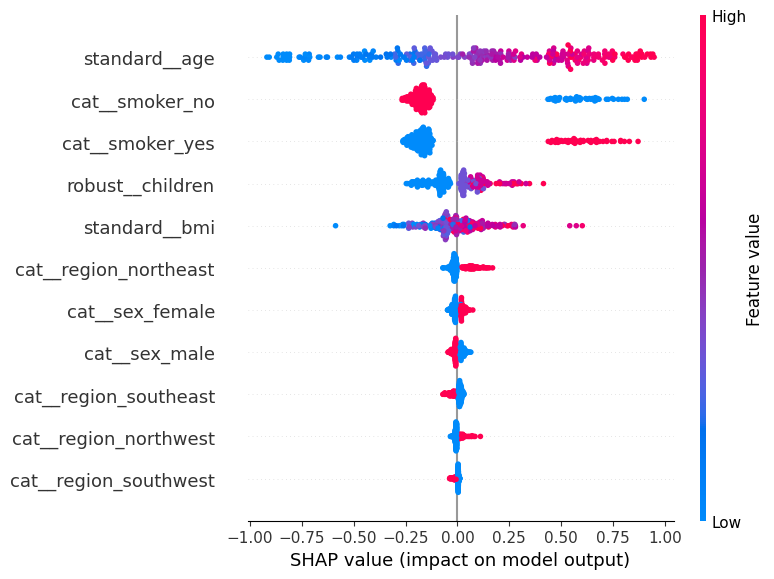

In [35]:
import shap

X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

explainer = shap.Explainer(gb_model, X_train_t, feature_names=feature_names)

shap_values = explainer(X_test_t)

shap.summary_plot(shap_values, features=X_test_t, feature_names=feature_names, show=False)
plt.show()